# EDAノートブック

本ノートブックは、分析業務で使うEDAを固定手順で実行するための定型版です。
可視化結果は相対パスで `reports/figures` に保存します。


## 固定EDA計画
1. データ読み込みと基本確認
2. 列型・記述統計の確認
3. 欠損率の集計と可視化
4. 数値列の分布確認
5. カテゴリ列の主要分布確認
6. 目的変数の分布と偏り確認
7. 数値特徴量の相関確認
8. 日付列の時系列傾向確認（存在時）
9. 観察結果サマリ


In [1]:
from pathlib import Path
import warnings

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")
warnings.filterwarnings("ignore", message="Glyph .* missing from font")
plt.rcParams["axes.unicode_minus"] = False

JP_FONT_CANDIDATES = [
    "Yu Gothic",
    "Meiryo",
    "MS Gothic",
    "Noto Sans CJK JP",
    "IPAexGothic",
    "IPAGothic",
    "TakaoGothic",
]


def configure_japanese_font() -> str:
    available = {f.name for f in fm.fontManager.ttflist}
    for name in JP_FONT_CANDIDATES:
        if name in available:
            plt.rcParams["font.family"] = name
            return name
    plt.rcParams["font.sans-serif"] = JP_FONT_CANDIDATES + list(plt.rcParams.get("font.sans-serif", []))
    return ""


selected_font = configure_japanese_font()
if selected_font:
    print(f"日本語フォント: {selected_font}")
else:
    print("日本語フォント候補が見つからないため、既定フォントで描画します。")

ENCODINGS = ("utf-8-sig", "utf-8", "cp932", "shift_jis", "euc_jp")

cwd = Path.cwd()
if (cwd / "configs" / "project_config.json").exists():
    analysis_root = cwd
elif (cwd.name == "notebooks") and (cwd.parent / "configs" / "project_config.json").exists():
    analysis_root = cwd.parent
elif (cwd / "artifacts" / "analysis_project" / "configs" / "project_config.json").exists():
    analysis_root = cwd / "artifacts" / "analysis_project"
else:
    analysis_root = cwd

FIG_DIR = analysis_root / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def load_csv_auto(path: Path):
    for enc in ENCODINGS:
        try:
            return pd.read_csv(path, encoding=enc), enc
        except UnicodeDecodeError:
            continue
    raise RuntimeError("CSVを既知エンコーディングで読み込めませんでした")


def is_pure_day_number_column(series: pd.Series) -> bool:
    numeric = pd.to_numeric(series, errors="coerce").dropna()
    if numeric.empty:
        return False
    if not np.all(np.isclose(numeric, np.round(numeric))):
        return False
    return bool(((numeric >= 1) & (numeric <= 31)).all())


日本語フォント: Yu Gothic


In [2]:
csv_rel = Path("data/train.csv")
candidates = [
    analysis_root / csv_rel,
    Path("data/train.csv"),
    Path("artifacts/analysis_project") / csv_rel,
]
csv_path = next((p for p in candidates if p.exists()), candidates[0])
df, used_encoding = load_csv_auto(csv_path)
target_col = "class"
if target_col not in df.columns:
    target_col = df.columns[-1]
date_col_hint = "None".strip() or None

print(f"読み込みエンコーディング: {used_encoding}")
print(f"行数: {len(df):,} / 列数: {df.shape[1]:,}")
print(f"目的変数列: {target_col}")
display(df.head(10))


読み込みエンコーディング: utf-8-sig
行数: 7,352 / 列数: 66
目的変数列: class


,id,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,...,Attr56,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,class
0,train_00000,0.120220,0.21236,0.40822,3.0325,-14.0180,0.524630,0.150520,3.70890,1.85660,...,0.066806,0.152640,0.92113,0.005798,3.9368,19.4080,39.486,9.2439,4.7491,0
1,train_00001,0.000682,0.29306,0.21687,1.7400,6.9237,0.000000,0.000682,2.41230,2.17940,...,0.198700,0.000964,0.81980,0.000000,12.4420,6.7041,49.080,7.4368,4.4472,0
2,train_00002,0.157400,0.39182,0.43705,3.7946,42.3610,0.000000,0.196110,1.55220,2.55600,...,0.069237,0.258800,0.92445,0.000000,17.6860,7.4207,22.333,16.3440,6.2870,0
3,train_00003,0.050751,0.46869,0.22326,1.7779,2.7648,0.210090,0.044704,1.13300,1.13580,...,0.119530,0.095569,0.88047,0.342120,4.7169,5.4450,102.970,3.5447,2.0774,0
4,train_00004,0.006350,0.16467,0.58556,5.3937,140.6200,0.088597,0.006350,4.20640,0.94532,...,-0.057843,0.009168,1.05780,0.045324,10.0190,11.3190,41.905,8.7102,4.1287,0
5,train_00005,0.121650,0.44103,0.38113,2.2439,19.4550,0.000000,0.121650,1.26740,2.67540,...,0.249350,0.217640,0.81095,0.240850,10.1220,7.4989,41.803,8.7315,8.5624,0
6,train_00006,0.186230,0.75169,0.12699,1.1742,19.0770,0.021180,0.229860,0.33033,2.62690,...,0.096838,0.750010,0.91261,0.000000,1198.9000,2.7447,101.290,3.6037,18.2370,0
7,train_00007,0.020031,0.34652,0.33593,2.7613,39.0500,0.000000,0.020031,1.88590,1.29750,...,0.212410,0.030652,0.80158,0.000862,9.7669,6.7570,53.651,6.8032,2.7412,0
8,train_00008,0.032578,0.40402,0.39057,1.9782,35.4360,-0.250280,0.032578,1.47520,1.34370,...,0.022538,0.054662,0.97591,0.000000,5.0517,7.8369,108.460,3.3652,6.3945,0
9,train_00009,0.045734,0.67960,0.15359,1.2998,-65.2420,0.000000,0.055060,0.47146,2.07460,...,0.074768,0.142740,0.97366,0.478490,5.2149,17.7720,90.141,4.0492,6.2098,0


## 1. データ概要


In [3]:
try:
    import os
    from pathlib import Path

    FIG_DIR = Path(FIG_DIR)
    FIG_DIR.mkdir(parents=True, exist_ok=True)

    print('データ概要')
    print(f'行数: {df.shape[0]}')
    print(f'列数: {df.shape[1]}')
    print('\n列名一覧')
    print(df.columns.tolist())
    print('\n先頭5行')
    print(df.head())
    print('\nデータ型')
    print(df.dtypes)

    mem_mb = df.memory_usage(deep=True).sum() / 1024**2
    print(f'\nメモリ使用量(MB): {mem_mb:.2f}')

    obj_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    print(f'数値列数: {len(num_cols)}')
    print(f'カテゴリ列数: {len(obj_cols)}')
    print('カテゴリ候補列:', obj_cols)

    if target_col in df.columns:
        print('\n目的変数の基本情報')
        print(df[target_col].describe())
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: overview_code: {_eda_exc}")
    dtype_summary = (
        df.dtypes.astype(str)
        .rename("dtype")
        .reset_index()
        .rename(columns={"index": "column"})
    )
    type_counts = dtype_summary["dtype"].value_counts().rename_axis("dtype").reset_index(name="count")
    print("列型サマリ")
    display(type_counts)
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    category_cols = [c for c in df.columns if c not in numeric_cols]
    print(f"数値列数: {len(numeric_cols)} / カテゴリ列数: {len(category_cols)}")
    display(dtype_summary.head(30))


データ概要
行数: 7352
列数: 66

列名一覧
['id', 'Attr1', 'Attr2', 'Attr3', 'Attr4', 'Attr5', 'Attr6', 'Attr7', 'Attr8', 'Attr9', 'Attr10', 'Attr11', 'Attr12', 'Attr13', 'Attr14', 'Attr15', 'Attr16', 'Attr17', 'Attr18', 'Attr19', 'Attr20', 'Attr21', 'Attr22', 'Attr23', 'Attr24', 'Attr25', 'Attr26', 'Attr27', 'Attr28', 'Attr29', 'Attr30', 'Attr31', 'Attr32', 'Attr33', 'Attr34', 'Attr35', 'Attr36', 'Attr37', 'Attr38', 'Attr39', 'Attr40', 'Attr41', 'Attr42', 'Attr43', 'Attr44', 'Attr45', 'Attr46', 'Attr47', 'Attr48', 'Attr49', 'Attr50', 'Attr51', 'Attr52', 'Attr53', 'Attr54', 'Attr55', 'Attr56', 'Attr57', 'Attr58', 'Attr59', 'Attr60', 'Attr61', 'Attr62', 'Attr63', 'Attr64', 'class']

先頭5行
            id     Attr1    Attr2    Attr3   Attr4     Attr5     Attr6  \
0  train_00000  0.120220  0.21236  0.40822  3.0325  -14.0180  0.524630   
1  train_00001  0.000682  0.29306  0.21687  1.7400    6.9237  0.000000   
2  train_00002  0.157400  0.39182  0.43705  3.7946   42.3610  0.000000   
3  train_00003  0.05075

C:\Users\hikeshita\AppData\Local\Temp\ipykernel_62020\3732938069.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


### 基本統計量

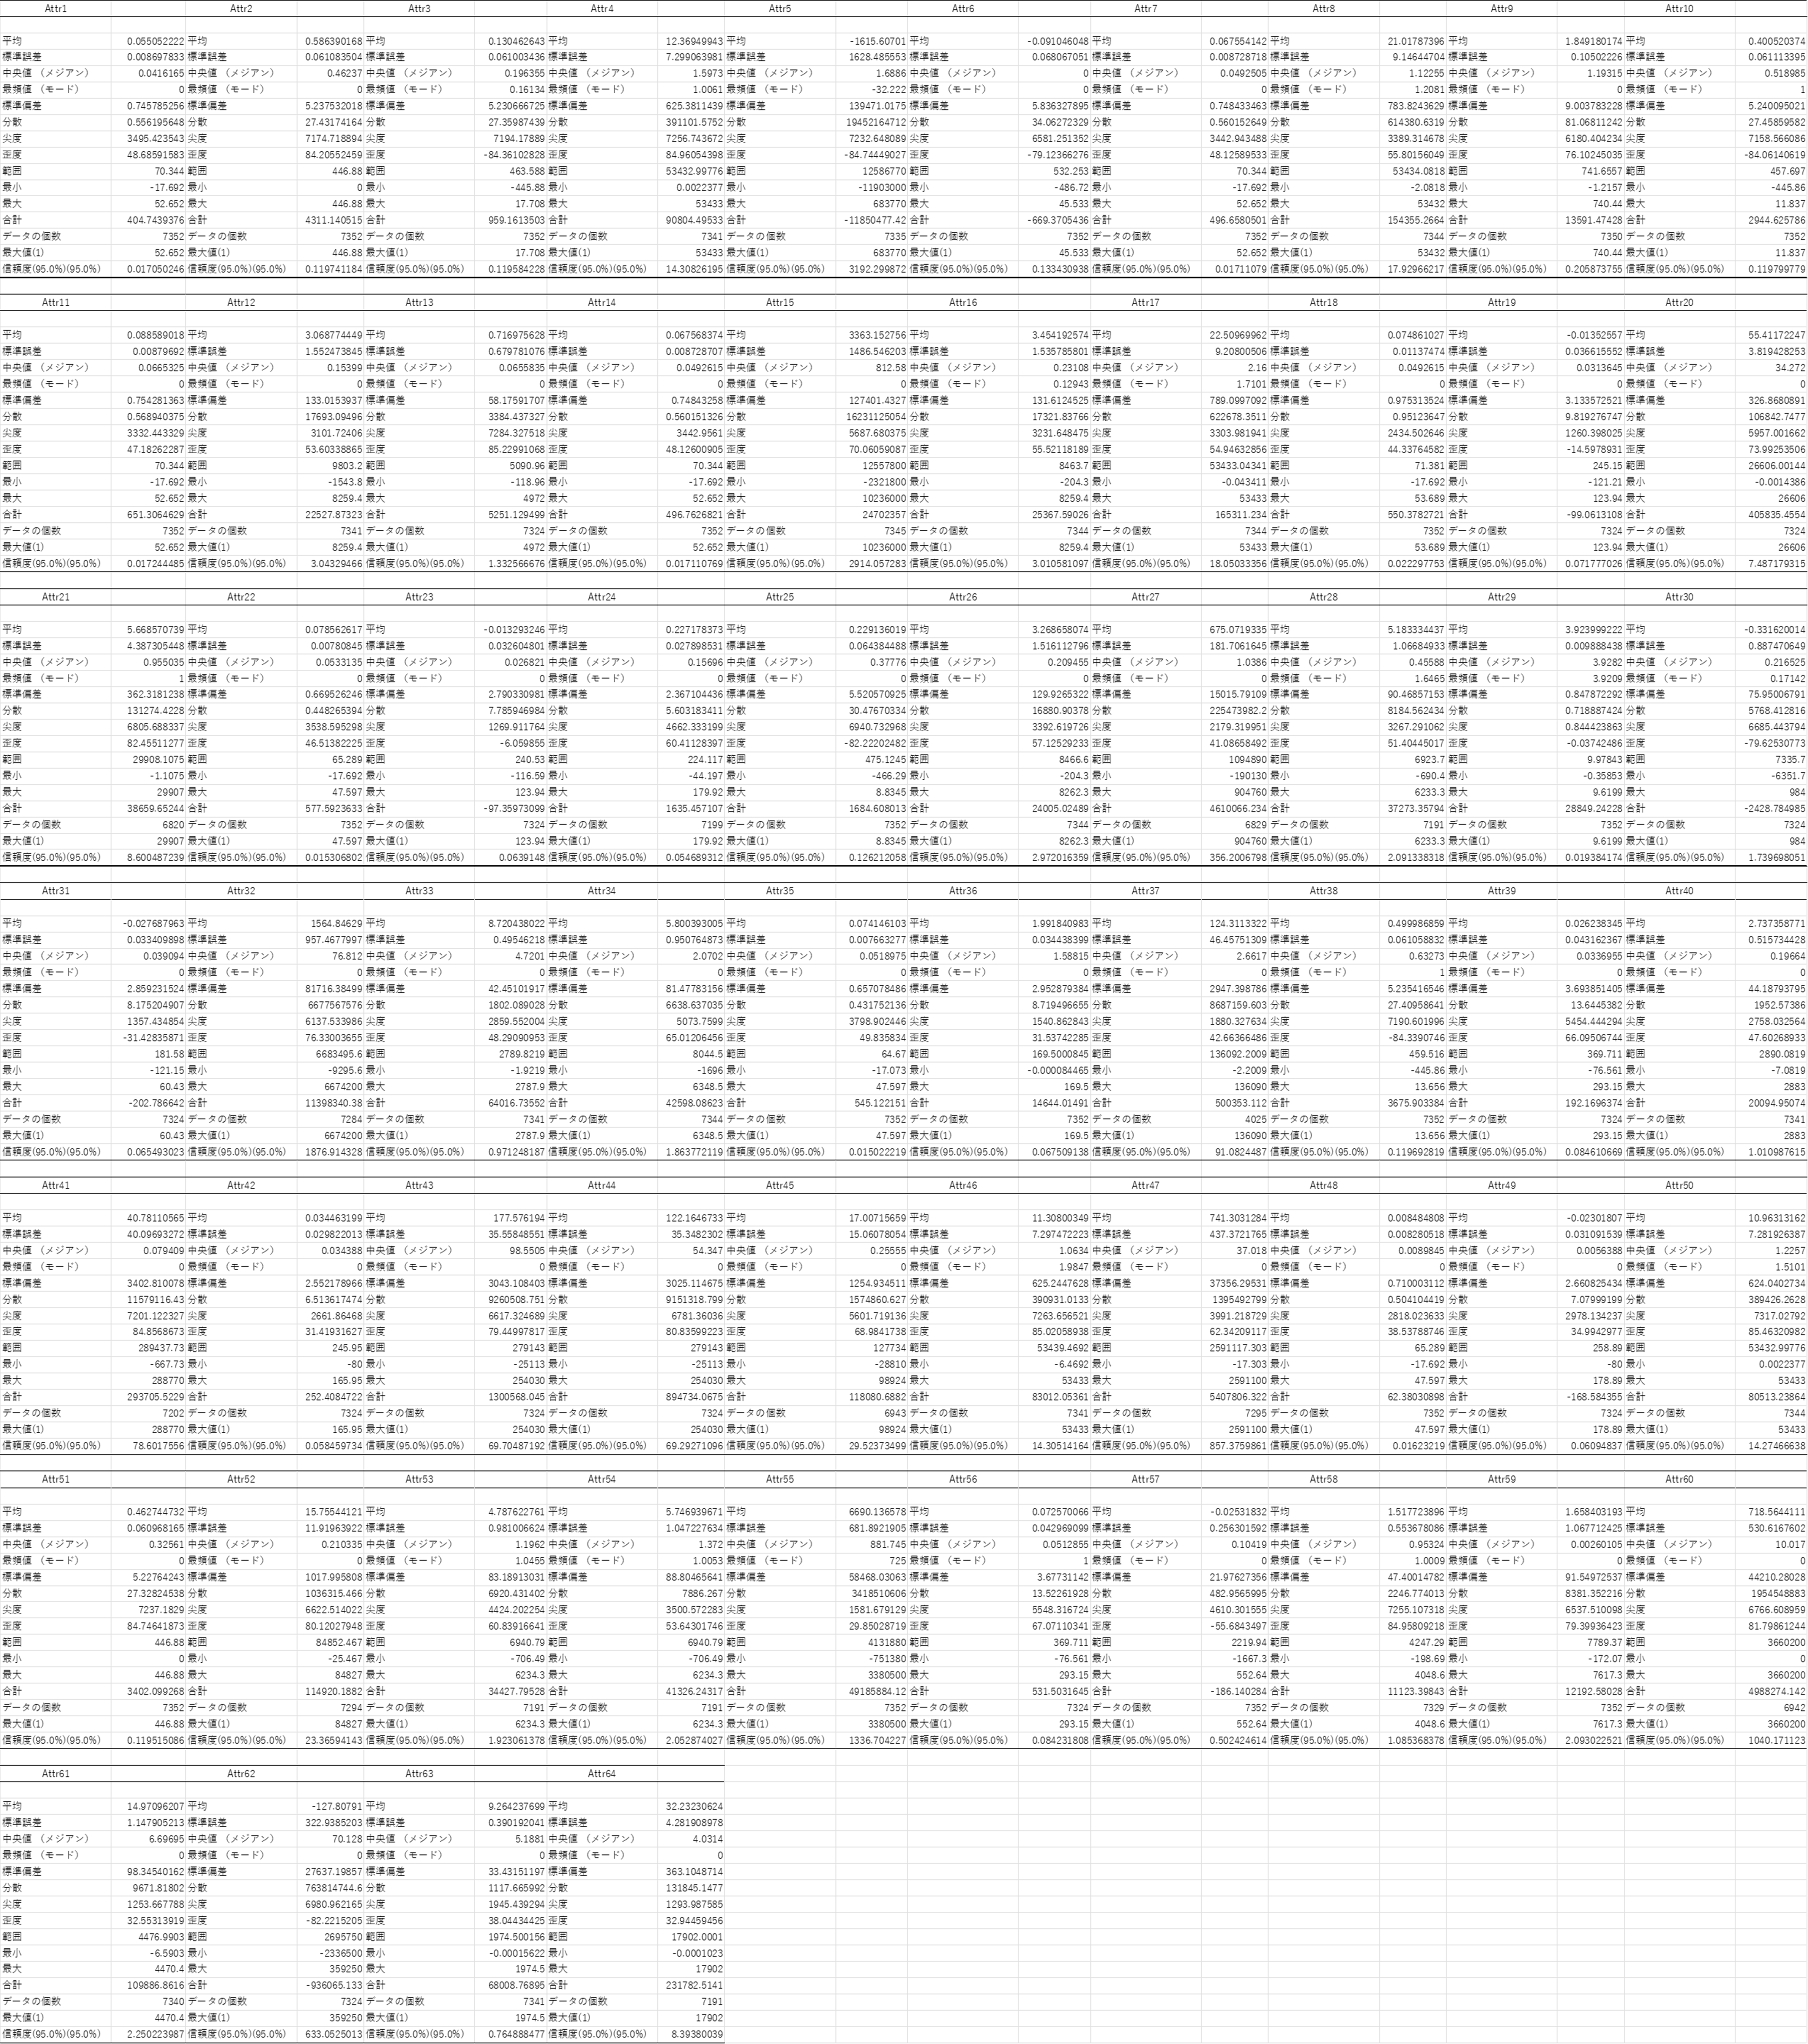


## 2. 欠損分析


欠損値集計
         欠損数     欠損率(%)
Attr37  3327  45.252992
Attr21   532   7.236126
Attr27   523   7.113711
Attr60   410   5.576714
Attr45   409   5.563112
Attr53   161   2.189880
Attr64   161   2.189880
Attr54   161   2.189880
Attr28   161   2.189880
Attr24   153   2.081066
Attr41   150   2.040261
Attr32    68   0.924918
Attr52    58   0.788901
Attr47    57   0.775299
Attr44    28   0.380849
Attr39    28   0.380849
Attr23    28   0.380849
Attr13    28   0.380849
Attr19    28   0.380849
Attr31    28   0.380849
Attr43    28   0.380849
Attr42    28   0.380849
Attr56    28   0.380849
Attr62    28   0.380849
Attr49    28   0.380849
Attr20    28   0.380849
Attr30    28   0.380849
Attr58    23   0.312840
Attr5     17   0.231230
Attr61    12   0.163221
Attr46    11   0.149619
Attr4     11   0.149619
Attr12    11   0.149619
Attr33    11   0.149619
Attr40    11   0.149619
Attr63    11   0.149619
Attr8      8   0.108814
Attr26     8   0.108814
Attr17     8   0.108814
Attr34     8   0.108814
Attr50    

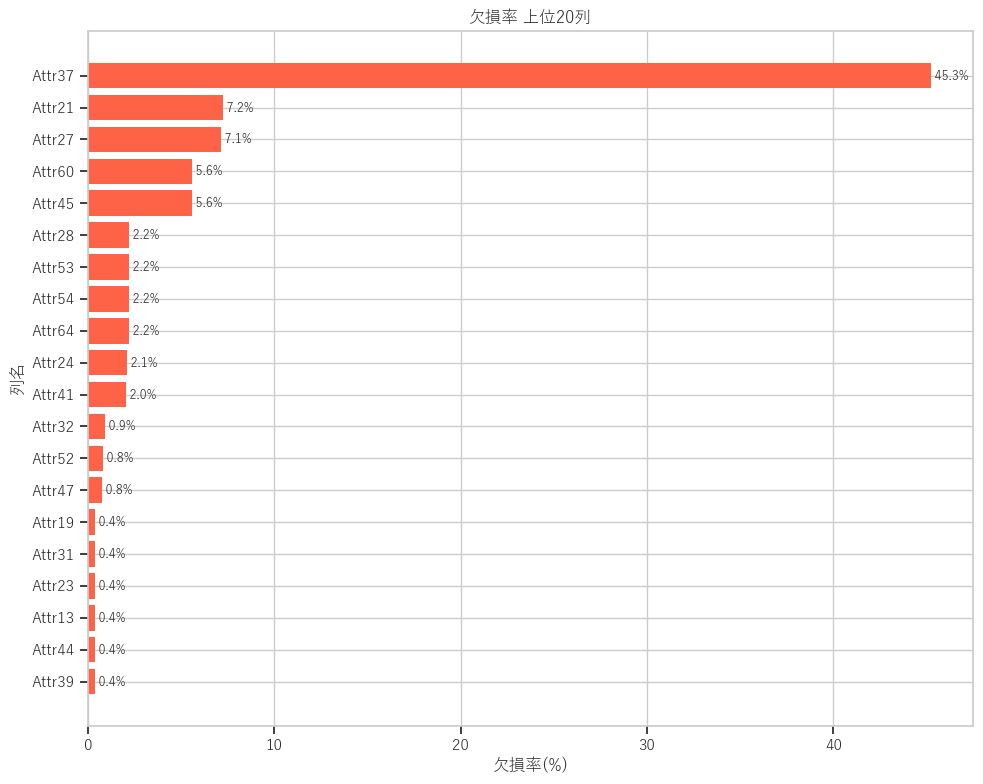

In [4]:
try:
    from pathlib import Path

    FIG_DIR = Path(FIG_DIR)
    FIG_DIR.mkdir(parents=True, exist_ok=True)

    missing_count = df.isnull().sum()
    missing_rate = (missing_count / len(df) * 100).sort_values(ascending=False)
    missing_df = pd.DataFrame({'欠損数': missing_count, '欠損率(%)': missing_count / len(df) * 100}).sort_values('欠損率(%)', ascending=False)

    print('欠損値集計')
    print(missing_df[missing_df['欠損数'] > 0])

    plot_df = missing_df[missing_df['欠損数'] > 0].head(20).sort_values('欠損率(%)', ascending=True)
    plt.figure(figsize=(10, 8))
    if len(plot_df) > 0:
        plt.barh(plot_df.index.astype(str), plot_df['欠損率(%)'], color='tomato')
        plt.xlabel('欠損率(%)')
        plt.ylabel('列名')
        plt.title('欠損率 上位20列')
        for i, v in enumerate(plot_df['欠損率(%)']):
            plt.text(v, i, f' {v:.1f}%', va='center', fontsize=9)
    else:
        plt.text(0.5, 0.5, '欠損値のある列はありません', ha='center', va='center')
        plt.title('欠損率 上位20列')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'missing_rate_top20.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: missing_code: {_eda_exc}")
    missing_rate = (df.isna().mean() * 100).sort_values(ascending=False)
    display(missing_rate.rename("欠損率(%)").to_frame().head(20))
    top_missing = missing_rate.head(20)
    fig, ax = plt.subplots(figsize=(12, 5))
    top_missing.plot(kind="bar", ax=ax, color="#4c78a8")
    ax.set_title("欠損率 上位20列")
    ax.set_ylabel("欠損率(%)")
    ax.set_xlabel("列名")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "missing_rate_top20.png", dpi=160, bbox_inches="tight")
    plt.show()


## 3. 数値特徴量の分布


数値列の要約統計量
         count         mean            std           min        25%  \
Attr1   7352.0     0.055052       0.745785 -1.769200e+01   0.000151   
Attr2   7352.0     0.586390       5.237532  0.000000e+00   0.252188   
Attr3   7352.0     0.130463       5.230667 -4.458800e+02   0.019711   
Attr4   7341.0    12.369499     625.381144  2.237700e-03   1.045200   
Attr5   7335.0 -1615.607010  139471.017461 -1.190300e+07 -51.194000   
...        ...          ...            ...           ...        ...   
Attr60  6942.0   718.564411   44210.280284  0.000000e+00   5.593425   
Attr61  7340.0    14.970962      98.345402 -6.590300e+00   4.514950   
Attr62  7324.0  -127.807910   27637.198566 -2.336500e+06  40.559500   
Attr63  7341.0     9.264238      33.431512 -1.562200e-04   3.092400   
Attr64  7191.0    32.232306     363.104871 -1.023000e-04   1.992350   

              50%         75%          max  
Attr1    0.041617    0.121915       52.652  
Attr2    0.462370    0.687345      446.880  
At

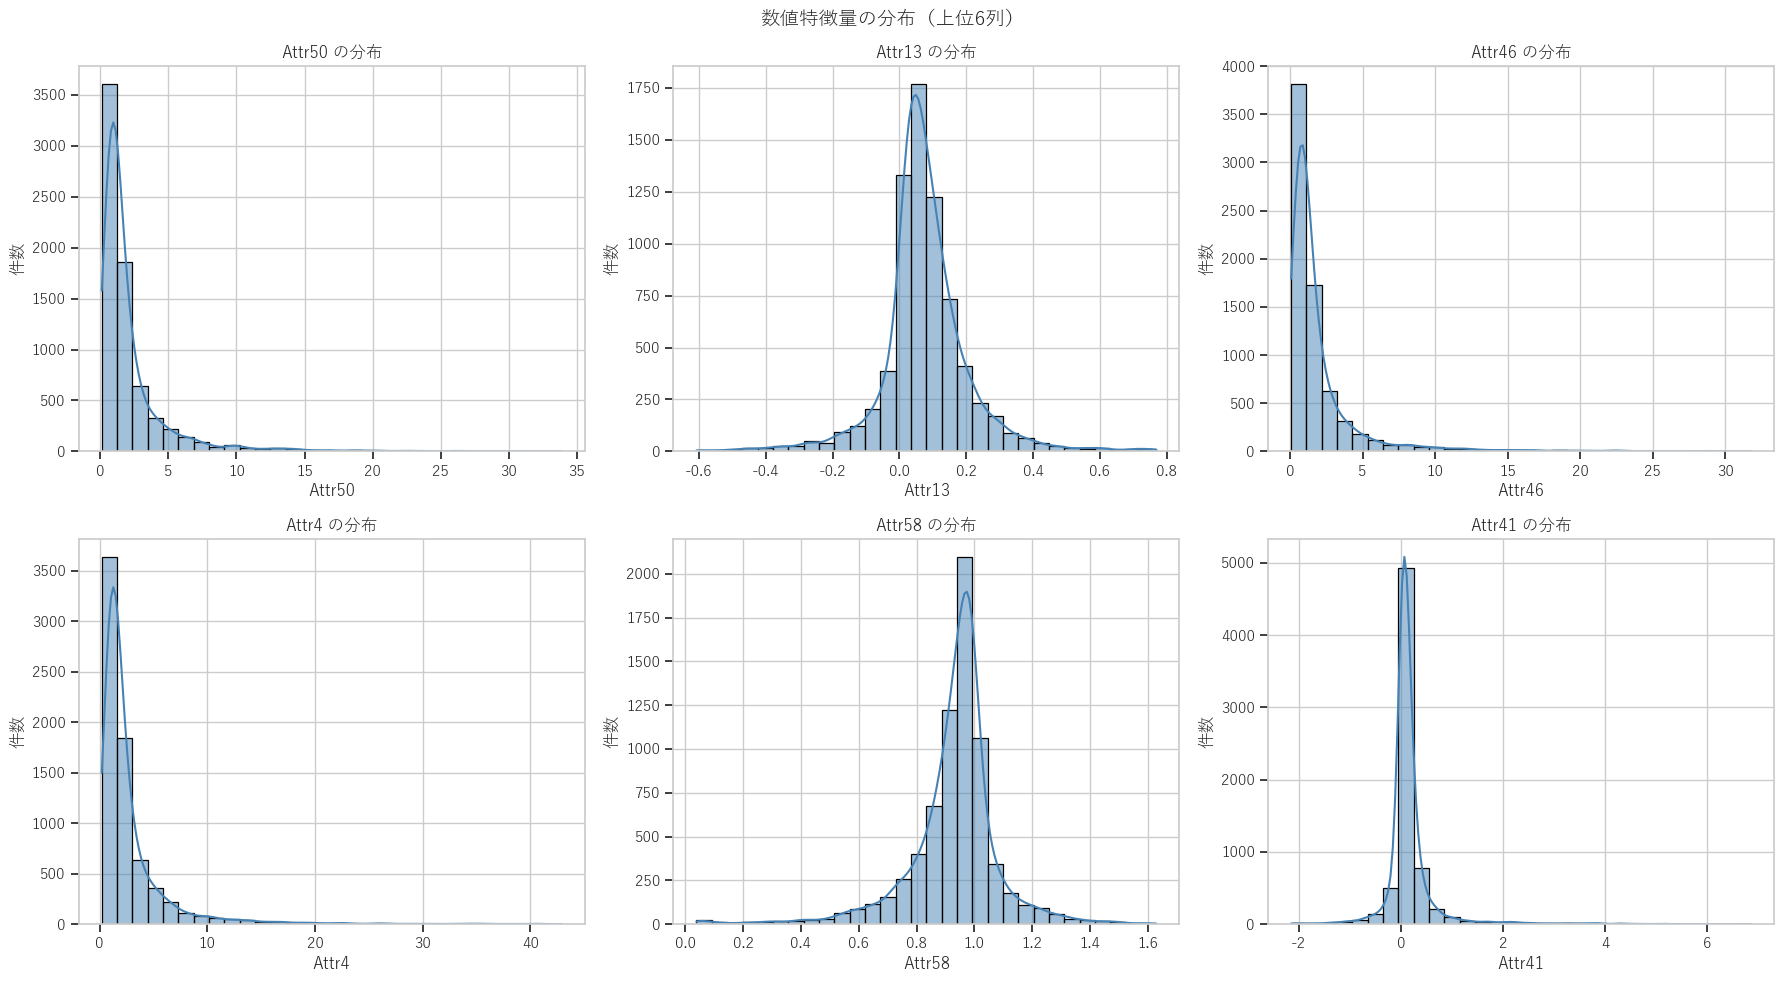

In [5]:
try:
    from pathlib import Path

    FIG_DIR = Path(FIG_DIR)
    FIG_DIR.mkdir(parents=True, exist_ok=True)

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col in num_cols:
        feature_num_cols = [c for c in num_cols if c != target_col]
    else:
        feature_num_cols = num_cols.copy()

    summary_df = df[feature_num_cols].describe().T if len(feature_num_cols) > 0 else pd.DataFrame()
    print('数値列の要約統計量')
    print(summary_df)

    if len(feature_num_cols) > 0:
        skew_abs = df[feature_num_cols].skew(numeric_only=True).abs().sort_values(ascending=False)
        top_cols = skew_abs.head(6).index.tolist()
    else:
        top_cols = []

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    for ax in axes:
        ax.axis('off')

    for i, col in enumerate(top_cols):
        ax = axes[i]
        ax.axis('on')
        s = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(s) > 0:
            q1, q99 = s.quantile([0.01, 0.99])
            s_plot = s[(s >= q1) & (s <= q99)]
            if s_plot.nunique() > 1:
                sns.histplot(s_plot, bins=30, kde=True, ax=ax, color='steelblue')
            else:
                ax.hist(s_plot, bins=10, color='steelblue')
        ax.set_title(f'{col} の分布')
        ax.set_xlabel(col)
        ax.set_ylabel('件数')

    fig.suptitle('数値特徴量の分布（上位6列）', fontsize=14)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'numeric_distribution_top6.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: numeric_code: {_eda_exc}")
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    if numeric_cols:
        display(df[numeric_cols].describe().T.head(20))
    target_col_local = "class"
    if target_col_local not in df.columns:
        target_col_local = df.columns[-1]
    plot_cols = [c for c in numeric_cols if c != target_col_local][:6]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i < len(plot_cols):
            col = plot_cols[i]
            sns.histplot(df[col], bins=30, ax=ax, color="#1f77b4")
            ax.set_title(f"{col} の分布")
        else:
            ax.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "numeric_distribution_top6.png", dpi=160, bbox_inches="tight")
    plt.show()


## 4. カテゴリ特徴量の分布


C:\Users\hikeshita\AppData\Local\Temp\ipykernel_62020\2523806007.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


カテゴリ列のユニーク数
id    7352
dtype: int64


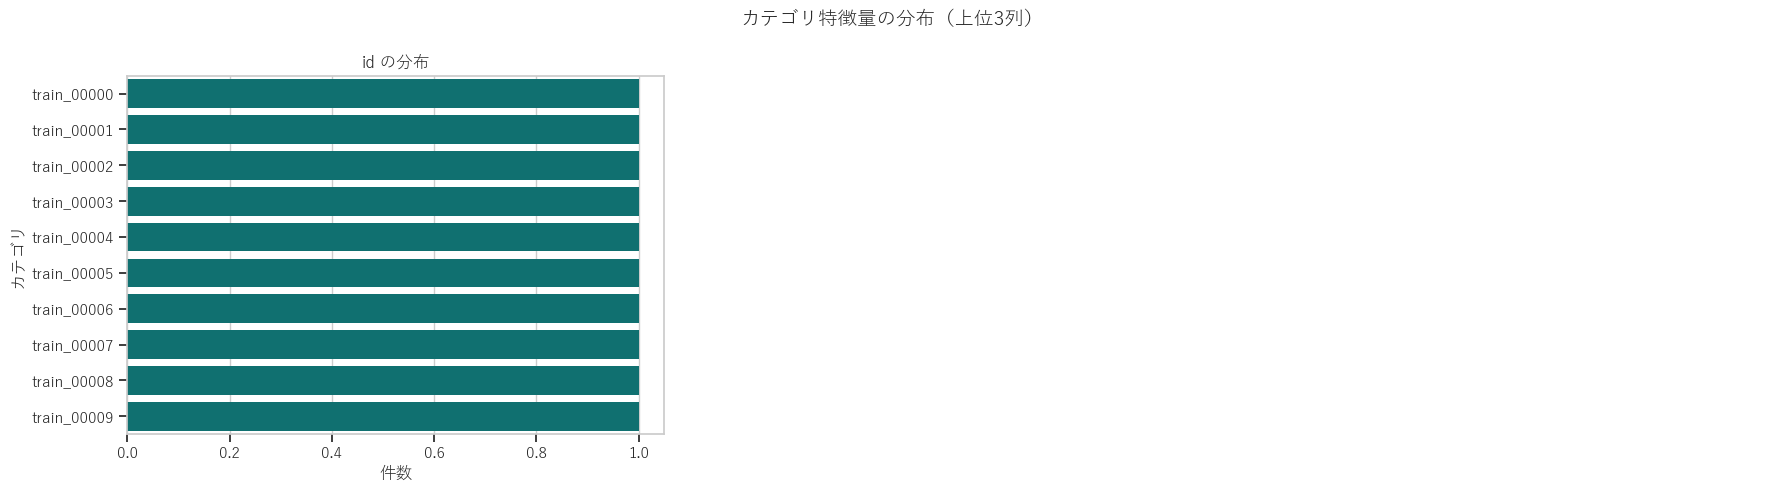

In [6]:
try:
    from pathlib import Path

    FIG_DIR = Path(FIG_DIR)
    FIG_DIR.mkdir(parents=True, exist_ok=True)

    cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    cat_cols = [c for c in cat_cols if c != target_col]
    cardinality = pd.Series({c: df[c].nunique(dropna=True) for c in cat_cols}).sort_values()
    print('カテゴリ列のユニーク数')
    print(cardinality)

    top_cols = cardinality.head(3).index.tolist()
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    for ax in axes:
        ax.axis('off')

    for i, col in enumerate(top_cols):
        ax = axes[i]
        ax.axis('on')
        vc = df[col].fillna('欠損').astype(str).value_counts().head(10)
        sns.barplot(x=vc.values, y=vc.index, ax=ax, color='teal')
        ax.set_title(f'{col} の分布')
        ax.set_xlabel('件数')
        ax.set_ylabel('カテゴリ')

    fig.suptitle('カテゴリ特徴量の分布（上位3列）', fontsize=14)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'categorical_distribution_top3.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: categorical_code: {_eda_exc}")
    category_cols = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
    plot_cols = category_cols[:3]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    for i, ax in enumerate(axes):
        if i < len(plot_cols):
            col = plot_cols[i]
            vc = df[col].astype(str).fillna("欠損").value_counts().head(10)
            vc.plot(kind="bar", ax=ax, color="#59a14f")
            ax.set_title(f"{col} 上位カテゴリ")
            ax.tick_params(axis="x", rotation=45)
        else:
            ax.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "categorical_distribution_top3.png", dpi=160, bbox_inches="tight")
    plt.show()


## 5. 目的変数分析


目的変数の分布
class
0    6988
1     364
Name: count, dtype: int64

目的変数の比率
class
0    95.05
1     4.95
Name: proportion, dtype: float64


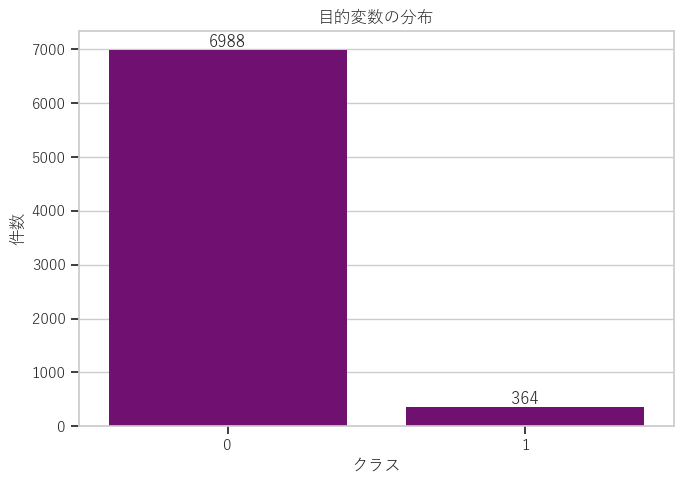


クラス間で平均差が大きい数値列 上位10
Attr55    4523.326653
Attr15    2335.365245
Attr5     1600.108428
Attr62    1444.146895
Attr47     725.940340
Attr60     694.940244
Attr27     330.613197
Attr32     200.674649
Attr37      63.325514
Attr41      42.682133
dtype: float64


In [7]:
try:
    from pathlib import Path

    FIG_DIR = Path(FIG_DIR)
    FIG_DIR.mkdir(parents=True, exist_ok=True)

    print('目的変数の分布')
    print(df[target_col].value_counts(dropna=False).sort_index())
    print('\n目的変数の比率')
    print((df[target_col].value_counts(dropna=False, normalize=True).sort_index() * 100).round(2))

    plt.figure(figsize=(7, 5))
    vc = df[target_col].value_counts(dropna=False).sort_index()
    sns.barplot(x=vc.index.astype(str), y=vc.values, color='purple')
    plt.title('目的変数の分布')
    plt.xlabel('クラス')
    plt.ylabel('件数')
    for i, v in enumerate(vc.values):
        plt.text(i, v, f'{v}', ha='center', va='bottom')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'target_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != target_col]
    if len(num_cols) > 0:
        diff_series = {}
        for c in num_cols:
            grp = df[[c, target_col]].dropna().groupby(target_col)[c].mean()
            if grp.shape[0] >= 2:
                diff_series[c] = grp.max() - grp.min()
        diff_series = pd.Series(diff_series).sort_values(ascending=False)
        print('\nクラス間で平均差が大きい数値列 上位10')
        print(diff_series.head(10))
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: target_code: {_eda_exc}")
    series = df[target_col]
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    if pd.api.types.is_numeric_dtype(series):
        uniq = series.dropna().nunique()
        if uniq > 20:
            sns.histplot(series.dropna(), bins=30, ax=ax[0], color="#f28e2b")
            ax[0].set_title("目的変数ヒストグラム")
            sns.boxplot(x=series.dropna(), ax=ax[1], color="#e15759")
            ax[1].set_title("目的変数ボックスプロット")
        else:
            vc = series.value_counts(dropna=False).sort_index()
            vc.plot(kind="bar", ax=ax[0], color="#f28e2b")
            ax[0].set_title("目的変数カテゴリ分布")
            (vc / vc.sum() * 100).round(2).plot(kind="bar", ax=ax[1], color="#e15759")
            ax[1].set_title("目的変数カテゴリ比率(%)")
    else:
        vc = series.astype(str).fillna("欠損").value_counts().head(20)
        vc.plot(kind="bar", ax=ax[0], color="#f28e2b")
        ax[0].set_title("目的変数カテゴリ分布")
        (vc / vc.sum() * 100).round(2).plot(kind="bar", ax=ax[1], color="#e15759")
        ax[1].set_title("目的変数カテゴリ比率(%)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "target_distribution.png", dpi=160, bbox_inches="tight")
    plt.show()


## 6. 相関分析


目的変数との相関
class     1.000000
Attr25   -0.061353
Attr10   -0.060909
Attr2     0.060658
Attr38   -0.060390
Attr3    -0.058883
Attr51    0.058636
Attr6    -0.055811
Attr35   -0.043522
Attr22   -0.038195
Attr24   -0.035449
Attr33    0.031301
Attr29   -0.025291
Attr48   -0.025219
Attr14   -0.022981
Name: class, dtype: float64


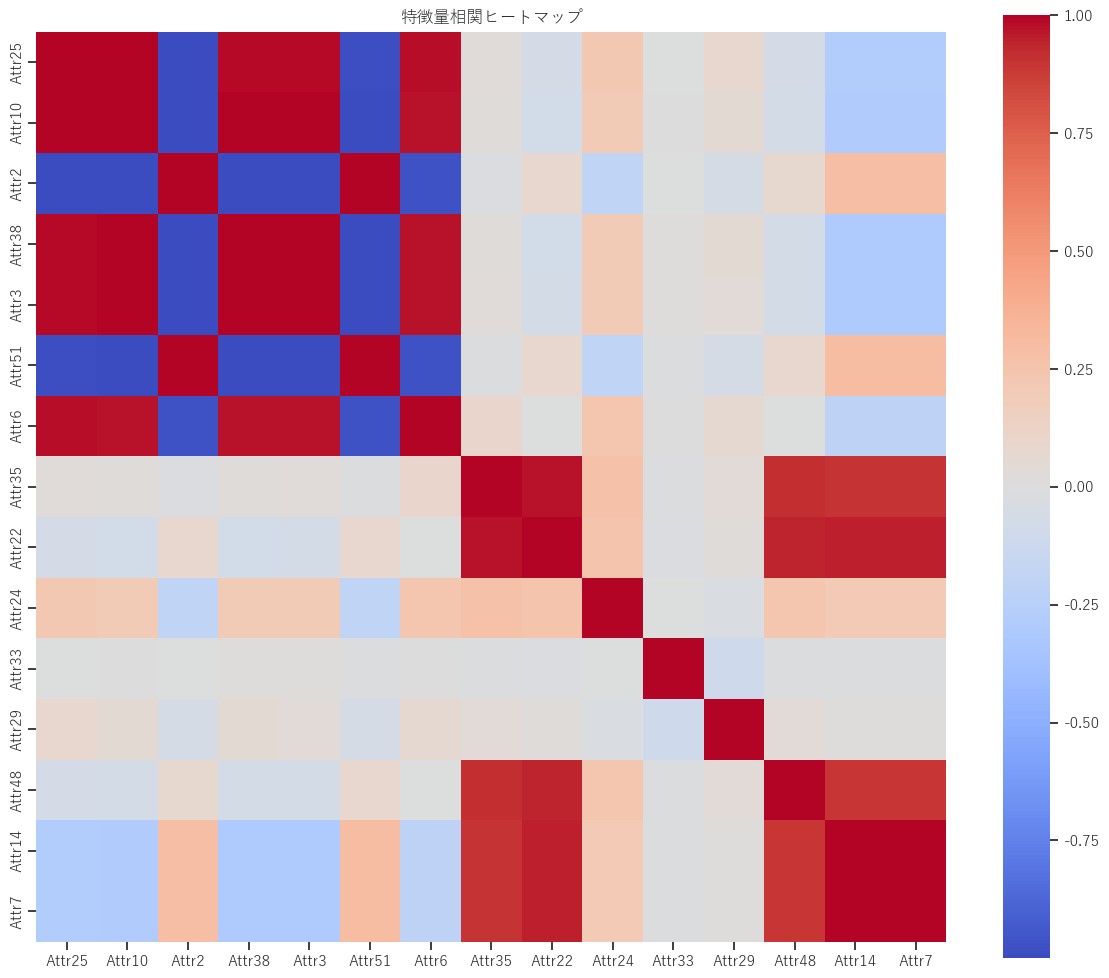

In [8]:
try:
    from pathlib import Path

    FIG_DIR = Path(FIG_DIR)
    FIG_DIR.mkdir(parents=True, exist_ok=True)

    num_df = df.select_dtypes(include=[np.number]).copy()
    if target_col in num_df.columns:
        corr_target = num_df.corr(numeric_only=True)[target_col].sort_values(key=lambda s: s.abs(), ascending=False)
        print('目的変数との相関')
        print(corr_target.head(15))

    feature_cols = [c for c in num_df.columns if c != target_col]
    if len(feature_cols) > 1:
        target_corr_abs = num_df[feature_cols].corrwith(num_df[target_col]).abs().sort_values(ascending=False) if target_col in num_df.columns else num_df[feature_cols].var().sort_values(ascending=False)
        top_cols = target_corr_abs.head(15).index.tolist()
        corr_mat = num_df[top_cols].corr()
    else:
        top_cols = feature_cols
        corr_mat = num_df[top_cols].corr() if len(top_cols) > 0 else pd.DataFrame()

    plt.figure(figsize=(12, 10))
    if corr_mat.shape[0] > 0:
        sns.heatmap(corr_mat, cmap='coolwarm', center=0, square=True)
        plt.title('特徴量相関ヒートマップ')
    else:
        plt.text(0.5, 0.5, '相関を計算できる数値列が不足しています', ha='center', va='center')
        plt.title('特徴量相関ヒートマップ')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: corr_code: {_eda_exc}")
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    fig, ax = plt.subplots(figsize=(10, 8))
    if len(numeric_cols) >= 2:
        corr = df[numeric_cols[:20]].corr(numeric_only=True)
        sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)
        ax.set_title("数値特徴量の相関ヒートマップ（先頭20列）")
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, "相関分析に十分な数値列がありません", ha="center", va="center", fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "feature_correlation_heatmap.png", dpi=160, bbox_inches="tight")
    plt.show()


## 7. 日付分析


日付列の探索結果
None


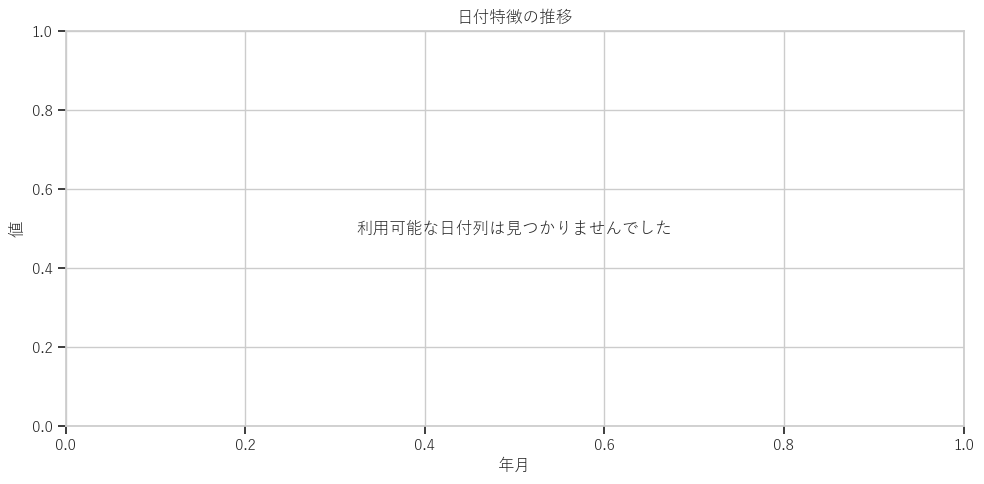

In [9]:
try:
    from pathlib import Path

    FIG_DIR = Path(FIG_DIR)
    FIG_DIR.mkdir(parents=True, exist_ok=True)

    def is_pure_day_number_column(s):
        x = pd.to_numeric(s, errors='coerce')
        valid = x.dropna()
        if len(valid) == 0:
            return False
        frac_close = np.isclose(valid % 1, 0)
        in_range = valid.between(1, 31)
        return bool((frac_close & in_range).mean() >= 0.95)

    def find_date_column(df, date_col_hint=None):
        if date_col_hint is not None and str(date_col_hint) not in ['None', ''] and date_col_hint in df.columns:
            if not is_pure_day_number_column(df[date_col_hint]):
                parsed = pd.to_datetime(df[date_col_hint], errors='coerce', infer_datetime_format=True)
                if parsed.notna().sum() > 0:
                    return date_col_hint, parsed
        for col in df.columns:
            if is_pure_day_number_column(df[col]):
                continue
            if df[col].dtype == 'object' or 'date' in str(col).lower() or 'time' in str(col).lower():
                parsed = pd.to_datetime(df[col], errors='coerce', infer_datetime_format=True)
                if parsed.notna().sum() >= max(10, int(len(df) * 0.3)):
                    return col, parsed
        return None, None

    date_col, parsed_dates = find_date_column(df, date_col_hint)
    print('日付列の探索結果')
    print(date_col)

    plt.figure(figsize=(10, 5))
    if date_col is not None and parsed_dates is not None:
        tmp = pd.DataFrame({'date': parsed_dates})
        if target_col in df.columns:
            tmp[target_col] = df[target_col].values
            trend = tmp.dropna(subset=['date']).groupby(tmp['date'].dt.to_period('M').astype(str))[target_col].mean()
            plt.plot(trend.index, trend.values, marker='o')
            plt.ylabel('目的変数平均')
        else:
            trend = tmp.dropna(subset=['date']).groupby(tmp['date'].dt.to_period('M').astype(str)).size()
            plt.plot(trend.index, trend.values, marker='o')
            plt.ylabel('件数')
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('年月')
        plt.title('日付特徴の推移')
    else:
        plt.text(0.5, 0.5, '利用可能な日付列は見つかりませんでした', ha='center', va='center')
        plt.title('日付特徴の推移')
        plt.xlabel('年月')
        plt.ylabel('値')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'date_feature_trend.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: date_code: {_eda_exc}")
    date_col = "None".strip() or date_col_hint
    fig, ax = plt.subplots(figsize=(12, 4))
    if date_col and date_col in df.columns and date_col != target_col:
        pure_day = is_pure_day_number_column(df[date_col])
        if pure_day:
            ax.axis("off")
            ax.text(0.5, 0.5, f"{date_col} は純粋な日番号列のため日付展開を行いません", ha="center", va="center", fontsize=12)
        else:
            parsed = pd.to_datetime(df[date_col], errors="coerce")
            valid = parsed.notna()
            if valid.sum() > 0:
                tmp = df.loc[valid, [target_col]].copy()
                tmp["_date"] = parsed.loc[valid]
                if pd.api.types.is_numeric_dtype(tmp[target_col]):
                    monthly = tmp.set_index("_date")[target_col].resample("M").mean()
                    monthly.plot(ax=ax, color="#4e79a7", marker="o")
                    ax.set_title("月次の目的変数平均")
                    ax.set_ylabel("平均値")
                else:
                    monthly = tmp.assign(_value=1).set_index("_date")["_value"].resample("M").sum()
                    monthly.plot(ax=ax, color="#4e79a7", marker="o")
                    ax.set_title("月次レコード件数")
                    ax.set_ylabel("件数")
                ax.set_xlabel("日付")
            else:
                ax.axis("off")
                ax.text(0.5, 0.5, f"{date_col} を日付として解釈できませんでした", ha="center", va="center", fontsize=12)
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, "日付分析対象列はありません", ha="center", va="center", fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "date_feature_trend.png", dpi=160, bbox_inches="tight")
    plt.show()


## 8. 観察結果サマリ


In [10]:
try:
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    missing_count = df.isnull().sum()
    missing_rate = (missing_count / len(df) * 100).sort_values(ascending=False)

    print('EDAサマリー')
    print(f'行数: {df.shape[0]}')
    print(f'列数: {df.shape[1]}')
    print(f'数値列数: {len(num_cols)}')
    print(f'カテゴリ列数: {len(cat_cols)}')
    print(f'欠損のある列数: {(missing_count > 0).sum()}')
    print('\n欠損率 上位10列')
    print(missing_rate[missing_rate > 0].head(10))

    if target_col in df.columns:
        print('\n目的変数集計')
        print(df[target_col].value_counts(dropna=False))
        print('\n目的変数比率(%)')
        print((df[target_col].value_counts(normalize=True, dropna=False) * 100).round(2))

    if len(num_cols) > 0:
        outlier_info = []
        for c in [x for x in num_cols if x != target_col][:20]:
            s = df[c].dropna()
            if len(s) == 0:
                continue
            q1 = s.quantile(0.25)
            q3 = s.quantile(0.75)
            iqr = q3 - q1
            if iqr == 0:
                continue
            outliers = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).mean() * 100
            outlier_info.append((c, outliers))
        outlier_df = pd.DataFrame(outlier_info, columns=['列名', '外れ値率(%)']).sort_values('外れ値率(%)', ascending=False)
        print('\n外れ値率 上位10列（先頭20数値列から算出）')
        print(outlier_df.head(10))
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: summary_code: {_eda_exc}")
    summary_rows = []
    summary_rows.append(f"レコード数: {len(df):,}")
    summary_rows.append(f"列数: {df.shape[1]:,}")
    summary_rows.append(f"欠損率上位列: {', '.join((df.isna().mean()*100).sort_values(ascending=False).head(3).index.tolist())}")
    summary_rows.append(f"数値列数: {len(df.select_dtypes(include=['number']).columns)}")
    summary_rows.append(f"カテゴリ列数: {len([c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])])}")
    summary_rows.append(f"目的変数候補: {target_col}")
    print("主要サマリ")
    for row in summary_rows:
        print(f"- {row}")


EDAサマリー
行数: 7352
列数: 66
数値列数: 65
カテゴリ列数: 1
欠損のある列数: 44

欠損率 上位10列
Attr37    45.252992
Attr21     7.236126
Attr27     7.113711
Attr60     5.576714
Attr45     5.563112
Attr53     2.189880
Attr64     2.189880
Attr54     2.189880
Attr28     2.189880
Attr24     2.081066
dtype: float64

目的変数集計
class
0    6988
1     364
Name: count, dtype: int64

目的変数比率(%)
class
0    95.05
1     4.95
Name: proportion, dtype: float64

外れ値率 上位10列（先頭20数値列から算出）
        列名    外れ値率(%)
5    Attr6  30.087051
14  Attr15  17.290674
4    Attr5  14.860259
11  Attr12  14.820869
18  Attr19  13.762971
15  Attr16  12.922113
0    Attr1  12.282372
16  Attr17  11.151961
7    Attr8  11.138344
17  Attr18  11.003808


C:\Users\hikeshita\AppData\Local\Temp\ipykernel_62020\1787494579.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
